In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("netflix_userbase.csv")
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [5]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ","_")
)
df['join_date'] = pd.to_datetime(df['join_date'], format='%d-%m-%y')
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%y')

In [6]:
df_ml = df.drop(columns=['user_id', 'join_date', 'last_payment_date'])
df_ml.head()


,subscription_type,monthly_revenue,country,age,gender,device,plan_duration
0,Basic,10,United States,28,Male,Smartphone,1 Month
1,Premium,15,Canada,35,Female,Tablet,1 Month
2,Standard,12,United Kingdom,42,Male,Smart TV,1 Month
3,Standard,12,Australia,51,Female,Laptop,1 Month
4,Basic,10,Germany,33,Male,Smartphone,1 Month


In [7]:
X = df_ml.drop(columns=['subscription_type'])
y = df_ml['subscription_type']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
numeric_features = ['monthly_revenue', 'age']
categorical_features = ['country','gender','device','plan_duration']

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['monthly_revenue', 'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'gender',
                                                   'device',
                                                   'plan_duration'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [16]:
from sklearn.metrics import classification_report , confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test , y_pred))

print("confusion Matrix:")
print(confusion_matrix(y_test , y_pred))

Classification Report:
              precision    recall  f1-score   support

       Basic       0.63      0.80      0.70       200
     Premium       0.54      0.63      0.58       147
    Standard       0.97      0.46      0.63       153

    accuracy                           0.65       500
   macro avg       0.71      0.63      0.64       500
weighted avg       0.71      0.65      0.64       500

confusion Matrix:
[[159  39   2]
 [ 54  93   0]
 [ 41  41  71]]


In [17]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

       Basic       0.65      0.65      0.65       200
     Premium       0.50      0.57      0.54       147
    Standard       0.66      0.58      0.62       153

    accuracy                           0.60       500
   macro avg       0.61      0.60      0.60       500
weighted avg       0.61      0.60      0.61       500



In [18]:
import numpy as np


onehot_features = model_rf.named_steps['preprocess'].transformers_[1][1].get_feature_names_out(categorical_features)
all_features = numeric_features + list(onehot_features)

importances = model_rf.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(15)


,feature,importance
1,age,0.380603
0,monthly_revenue,0.154123
10,country_United Kingdom,0.082744
8,country_Mexico,0.080867
7,country_Italy,0.046696
5,country_France,0.039803
6,country_Germany,0.028887
3,country_Brazil,0.028128
9,country_Spain,0.021256
2,country_Australia,0.018025


Classification Report:

              precision    recall  f1-score   support

       Basic       0.63      0.80      0.70       200
     Premium       0.54      0.63      0.58       147
    Standard       0.97      0.46      0.63       153

    accuracy                           0.65       500
   macro avg       0.71      0.63      0.64       500
weighted avg       0.71      0.65      0.64       500



<Figure size 600x500 with 0 Axes>

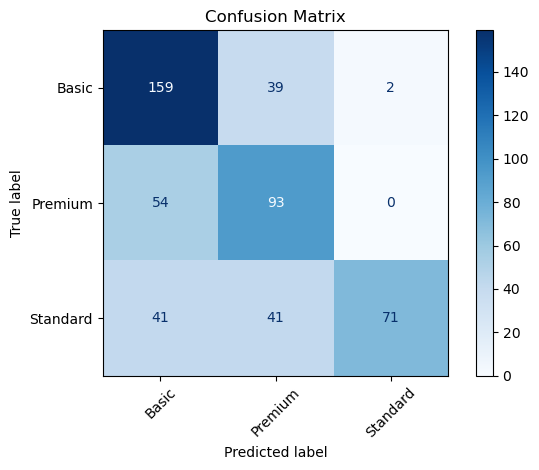

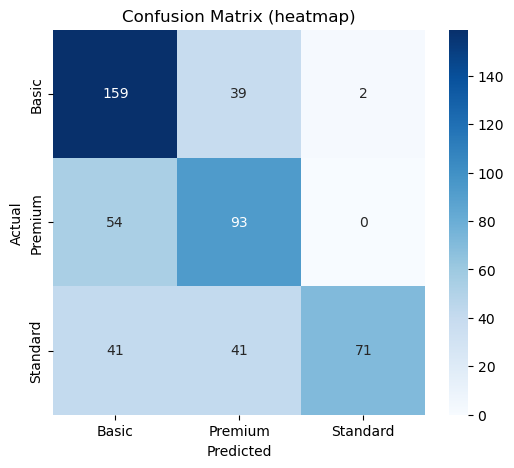

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# y_test, y_pred must exist from pipeline run
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#  heatmap:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (heatmap)")
plt.show()

                   feature  importance
0                      age    0.380603
1          monthly_revenue    0.154123
2   country_United Kingdom    0.082744
3           country_Mexico    0.080867
4            country_Italy    0.046696
5           country_France    0.039803
6          country_Germany    0.028887
7           country_Brazil    0.028128
8            country_Spain    0.021256
9        country_Australia    0.018025
10         device_Smart TV    0.016945
11       device_Smartphone    0.015875
12             gender_Male    0.015217
13           device_Laptop    0.015096
14   country_United States    0.015082
15           device_Tablet    0.014867
16           gender_Female    0.014527
17          country_Canada    0.011261
18   plan_duration_1 Month    0.000000


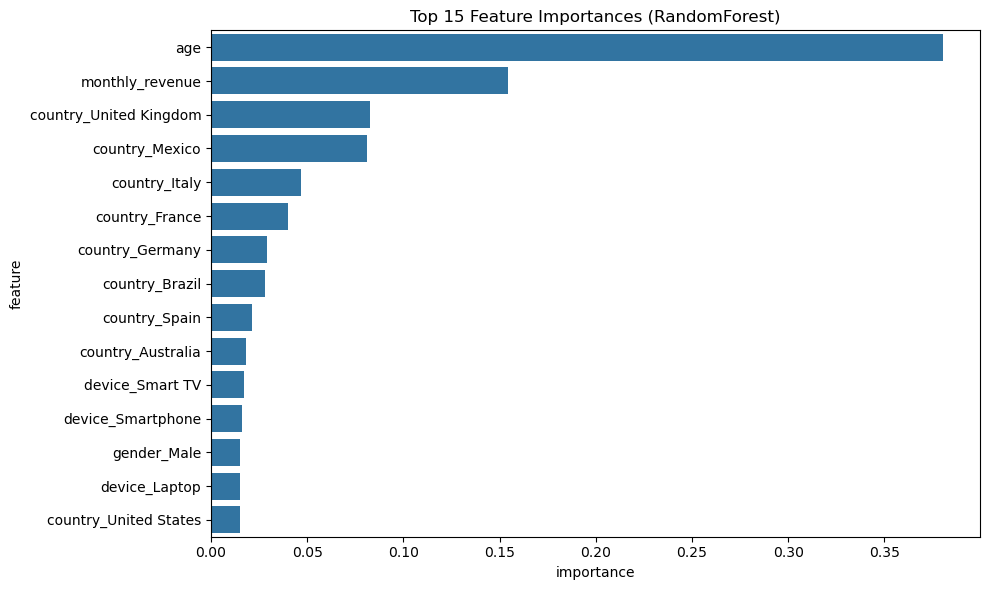

In [25]:

ohe = model_rf.named_steps['preprocess'].transformers_[1][1]  # OneHotEncoder object
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_feature_names

importances = model_rf.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
print(feat_imp.head(20))

# Plot top 15
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title("Top 15 Feature Importances (RandomForest)")
plt.tight_layout()
plt.show()


In [26]:
import joblib
joblib.dump(model_rf, "models/ott_subscription_model_rf.joblib")


['models/ott_subscription_model_rf.joblib']

In [27]:
import os
os.makedirs("models", exist_ok=True)

import joblib
joblib.dump(model_rf, "models/ott_subscription_model_rf.joblib")

with open("models/model_info.txt", "w") as f:
    f.write("model: RandomForestClassifier\n")
    f.write("features: " + ", ".join(all_feature_names) + "\n")
    f.write("dataset_path: netflix_userbase.csv\n")

print("Model saved successfully!")


Model saved successfully!


In [28]:
os.makedirs("models", exist_ok=True)


In [30]:

import os
import pandas as pd
import joblib

# output path
os.makedirs("visuals", exist_ok=True)
out_path = "visuals/predictions_test_set.csv"

# Helper: try to use in-memory variables, else rebuild
try:
    X_test  # noqa: F821
    y_test  # noqa: F821
    model_rf  # noqa: F821
    print("Using existing X_test, y_test and model_rf from notebook memory.")
    model = model_rf
except NameError:
    # Try to load saved model
    print("X_test / y_test or model_rf not found in memory. Attempting to load saved model and reconstruct test split...")
    # load model
    model_file = "models/ott_subscription_model_rf.joblib"
    if os.path.exists(model_file):
        model = joblib.load(model_file)
        print(f"Loaded model from {model_file}")
    else:
        raise FileNotFoundError(
            f"Model not found in memory and {model_file} does not exist. "
            "Run training or save model as models/ott_subscription_model_rf.joblib first."
        )

    # Rebuild X_test / y_test from CSV using same preprocessing as training
    csv_path = "netflix_userbase.csv"  # your dataset in project root
    if not os.path.exists(csv_path):
        # if your notebook uses a different relative path, adjust here
        csv_path = "../data/netflix_userbase.csv" if os.path.exists("../data/netflix_userbase.csv") else None
    if csv_path is None or not os.path.exists(csv_path):
        raise FileNotFoundError("Cannot find netflix_userbase.csv in current folder or ../data/. Update csv_path in the script.")
    df = pd.read_csv(csv_path)

    # clean columns (same steps used before)
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
    # convert dates (if present)
    if 'join_date' in df.columns:
        df['join_date'] = pd.to_datetime(df['join_date'], format='%d-%m-%y', errors='coerce')
    if 'last_payment_date' in df.columns:
        df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%y', errors='coerce')

    # Prepare X, y same as training
    if 'subscription_type' not in df.columns:
        raise KeyError("subscription_type column not found in CSV. Check the CSV or column cleaning step.")
    X = df.drop(columns=['user_id', 'join_date', 'last_payment_date', 'subscription_type'], errors='ignore')
    y = df['subscription_type']

    # same feature sets used in training
    numeric_features = ['monthly_revenue', 'age']
    categorical_features = ['country', 'gender', 'device', 'plan_duration']

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Reconstructed X_test and y_test from CSV.")

# At this point we should have: model, X_test, y_test
# Convert X_test to DataFrame if it's not already (it should be)
if not isinstance(X_test, pd.DataFrame):
    # If X_test is numpy array, try to rebuild as DataFrame using column names from X
    try:
        X_test = pd.DataFrame(X_test, columns=X.columns)
    except Exception:
        X_test = pd.DataFrame(X_test)

# Predict & get probabilities
preds = model.predict(X_test)
probs = None
if hasattr(model, "predict_proba"):
    try:
        probs = model.predict_proba(X_test)
    except Exception:
        # If pipeline has preprocessing that expects raw X, ensure we pass raw X_test (we assume X_test is raw)
        probs = None

# Build output DataFrame
out = X_test.reset_index(drop=True).copy()
out['actual_subscription'] = y_test.reset_index(drop=True)
out['predicted_subscription'] = preds

# probabilities per class if available
if probs is not None:
    classes = list(model.classes_)
    for i, cls in enumerate(classes):
        out[f'prob_{cls}'] = probs[:, i]
else:
    print("Model does not support predict_proba or probabilities could not be computed. CSV will contain predictions but not probabilities.")

# Save CSV
out.to_csv(out_path, index=False)
print(f"Saved predictions CSV to: {os.path.abspath(out_path)}")


Using existing X_test, y_test and model_rf from notebook memory.
Saved predictions CSV to: C:\Users\shashwat\visuals\predictions_test_set.csv
